In [1]:
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install timm albumentations scikit-learn

  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.


In [3]:
%pip install "numpy<2.0"

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.


## Set up Path

In [1]:
import os

BASE_DIR = os.getcwd()

TRAIN_DIR = os.path.join(BASE_DIR, 'dataset', 'train')
TEST_DIR = os.path.join(BASE_DIR, 'dataset', 'test')

print(f'Training data directory: {TRAIN_DIR}')
print(f'Testing data directory: {TEST_DIR}')

Training data directory: d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset\train
Testing data directory: d:\Penyimpanan\Documents\SEMESTER 6\data-lab\data-comp\data-analytics-competition-find-it-2026\dataset\test


In [2]:
print(f"Jumlah file train: {len(os.listdir(TRAIN_DIR))}")
print(f"Jumlah file test: {len(os.listdir(TEST_DIR))}")

Jumlah file train: 6
Jumlah file test: 404


## Load Dataset

In [3]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(TRAIN_DIR, transform=transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

print("Classes:", train_data.classes)

Classes: ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']


fake_mannequin


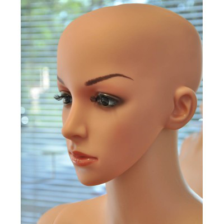

fake_mask


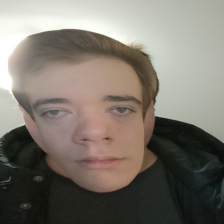

fake_printed


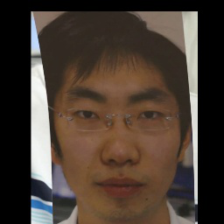

fake_screen


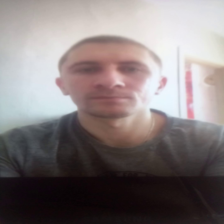

fake_unknown


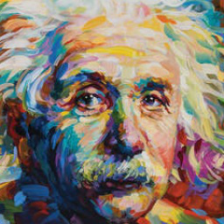

realperson


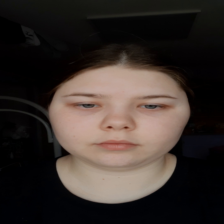

In [4]:
from IPython.display import display
from torchvision.transforms.functional import to_pil_image

num_classes = len(train_data.classes)

# Ambil satu batch
images, labels = next(iter(train_loader))

# Kelompokkan berdasarkan label
unique_labels = {}
for img, label in zip(images, labels):
    label_idx = label.item()
    if label_idx not in unique_labels:
        unique_labels[label_idx] = img
    if len(unique_labels) == num_classes:
        break

# Tampilkan 1 gambar per class (tanpa matplotlib)
for idx in range(num_classes):
    if idx in unique_labels:
        print(train_data.classes[idx])
        display(to_pil_image(unique_labels[idx]))

## Augmentation

In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(p=0.3),
    A.ImageCompression(quality_lower=50, quality_upper=100, p=0.3),
    A.Normalize(),
    ToTensorV2(),
])

valid_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2(),
])

C:\Users\asus\AppData\Local\Temp\ipykernel_12796\3901861090.py:9: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=50, quality_upper=100, p=0.3),


## Dataloader

In [6]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)

train_idx, val_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.2,
    stratify=dataset.targets
)

from torch.utils.data import Subset

train_data = Subset(dataset, train_idx)
val_data = Subset(dataset, val_idx)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

c:\Users\asus\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\asus\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Model ViT

In [7]:
import timm
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=6)

model.to(device)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

## Loss + Optimizer

In [8]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=3e-5)

## Metric Macro F1

In [9]:
from sklearn.metrics import f1_score

def compute_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

## Training Loop

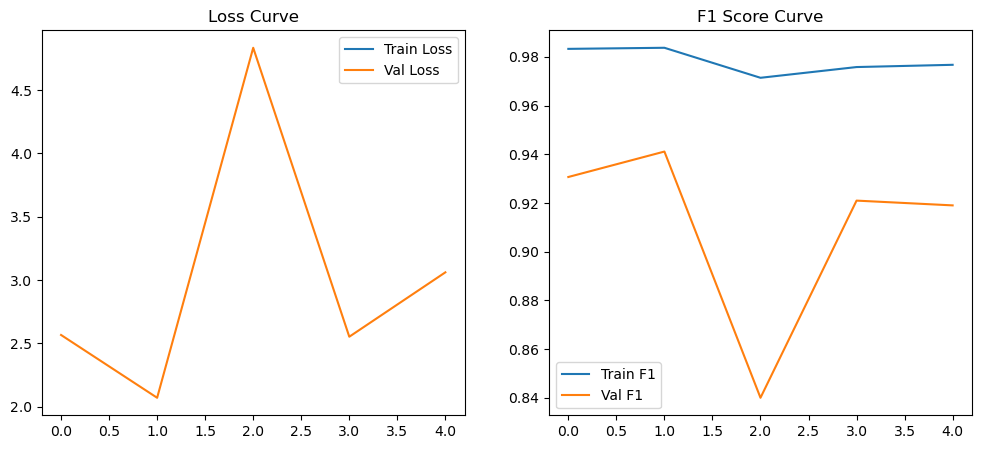

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# LOSS
plt.subplot(1,2,1)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")

# F1
plt.subplot(1,2,2)
plt.plot(train_f1s, label='Train F1')
plt.plot(val_f1s, label='Val F1')
plt.legend()
plt.title("F1 Score Curve")

plt.show()

## Inference Test

In [28]:
class TestImageDataset(torch.utils.data.Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.image_paths = sorted([
            os.path.join(test_dir, f)
            for f in os.listdir(test_dir)
            if os.path.isfile(os.path.join(test_dir, f))
            and f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = datasets.folder.default_loader(path)  # PIL Image
        if self.transform is not None:
            image = self.transform(image)
        filename = os.path.basename(path)
        return image, filename


test_dataset = TestImageDataset(TEST_DIR, transform=to_albumentations(valid_transform))
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
predictions = []
ids = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        predictions.extend(preds)
        ids.extend(filenames)

c:\Users\asus\anaconda3\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


## Save Submission

In [32]:
import pandas as pd
import os

idx_to_class = {v:k for k,v in dataset.class_to_idx.items()}

labels = [idx_to_class[p] for p in predictions]
ids_clean = [os.path.splitext(f)[0] for f in ids]

submission = pd.DataFrame({
    "id": ids_clean,
    "label": labels
})

submission.to_csv("submission.csv", index=False)

print("Submission file 'submission.csv' berhasil dibuat.")

Submission file 'submission.csv' berhasil dibuat.


In [34]:
print(submission.head())
print(submission.shape)

         id           label
0  test_001     fake_screen
1  test_002  fake_mannequin
2  test_003      realperson
3  test_004      realperson
4  test_005    fake_printed
(404, 2)


In [35]:
print(submission.tail())

           id           label
399  test_400      realperson
400  test_401       fake_mask
401  test_402      realperson
402  test_403    fake_unknown
403  test_404  fake_mannequin


In [2]:
import torch

with open("gpu_info.txt", "w") as f:
    f.write(f"GPU Available: {torch.cuda.is_available()}\n")
    if torch.cuda.is_available():
        f.write(f"GPU Name: {torch.cuda.get_device_name(0)}\n")
        f.write(f"CUDA Version: {torch.version.cuda}\n")
    
print("✅ GPU info disimpan ke gpu_info.txt")

✅ GPU info disimpan ke gpu_info.txt


In [3]:
import torch

print(torch.cuda.is_available())  # True jika GPU terdeteksi
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))  # Nama GPU
else:
    print("GPU tidak terdeteksi, training akan berjalan di CPU.")

False
GPU tidak terdeteksi, training akan berjalan di CPU.
